In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from jcopml.pipeline import num_pipe, cat_pipe
from jcopml.utils import save_model, load_model
from jcopml.plot import plot_missing_value
from jcopml.feature_importance import mean_score_decrease


In [3]:
df = pd.read_csv("data/carprice.csv", index_col="ID")
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_CC,Power_bhp,Seats,Price
ID,,,,,,,,,,,,
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74
6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08,1461.0,63.10,5.0,3.50


In [4]:
df.Name.value_counts()

Name
Mahindra XUV500 W8 2WD                       49
Maruti Swift VDI                             45
Maruti Swift Dzire VDI                       34
Honda City 1.5 S MT                          34
Maruti Swift VDI BSIV                        31
                                             ..
Hyundai Verna 1.6 i ABS                       1
Porsche Panamera 2010 2013 Diesel             1
Nissan Sunny XV D                             1
Tata Indigo XL Grand Petrol                   1
Volkswagen Vento Magnific 1.6 Comfortline     1
Name: count, Length: 1849, dtype: int64

# Akan kita Ekstrak kolom Nama

In [5]:

df['Brand'] = df['Name'].apply(lambda x: x.split()[0])

df['Model'] = df['Name'].apply(lambda x: ' '.join(x.split()[1:3]))

df['Variant'] = df['Name'].apply(lambda x: ' '.join(x.split()[3:]))

df.drop(columns="Name",inplace=True)


In [6]:
df.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_CC,Power_bhp,Seats,Price,Brand,Model,Variant
ID,,,,,,,,,,,,,,
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,Hyundai,Creta 1.6,CRDi SX Option
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50,Honda,Jazz V,
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,Maruti,Ertiga VDI,
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,Audi,A4 New,2.0 TDI Multitronic
6,Jaipur,2013,86999,Diesel,Manual,First,23.08,1461.0,63.10,5.0,3.50,Nissan,Micra Diesel,XV


Location               0
Year                   0
Kilometers_Driven      0
Fuel_Type              0
Transmission           0
Owner_Type             0
Mileage_kmpl           2
Engine_CC             36
Power_bhp            142
Seats                 42
Price                  0
Brand                  0
Model                  0
Variant                0
dtype: int64

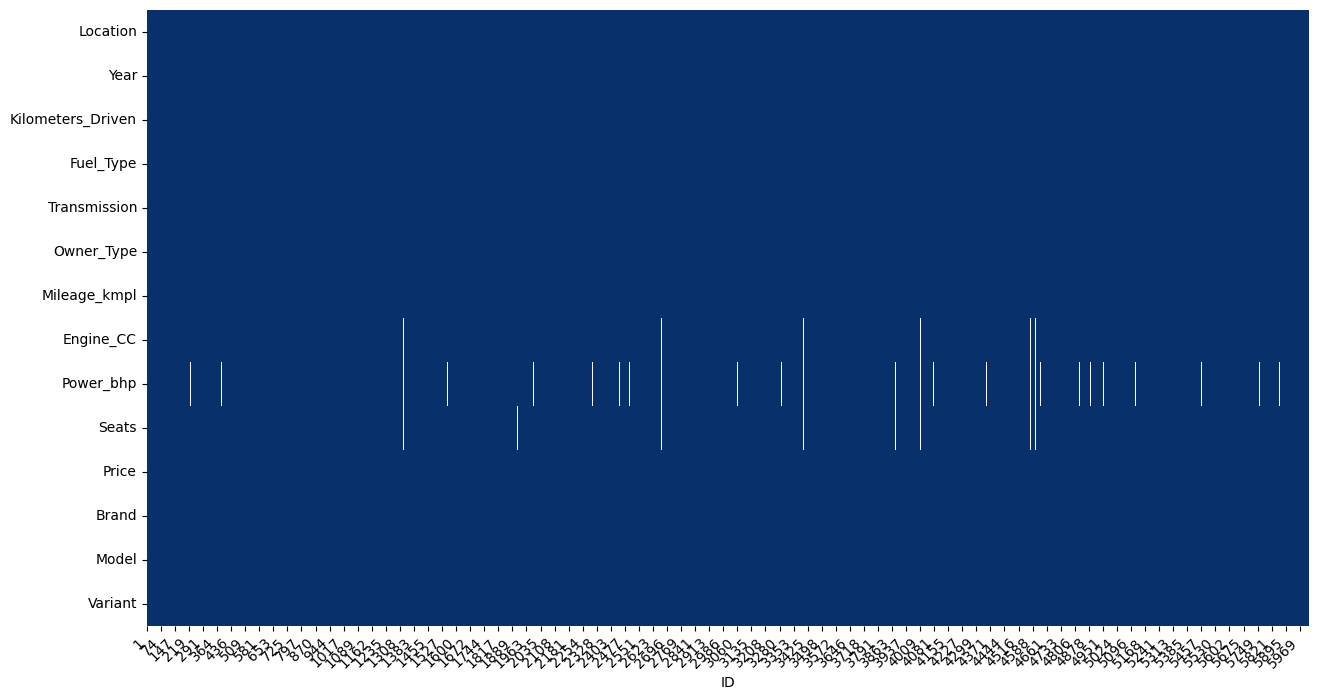

In [7]:
plot_missing_value(df)
df.isnull().sum()

DATA SET SPLITTING

In [8]:
X = df.drop(columns="Price")
y = df.Price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4762, 13), (1191, 13), (4762,), (1191,))

Traning

In [9]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from jcopml.tuning import grid_search_params as gsp

In [10]:
X_train.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_kmpl,Engine_CC,Power_bhp,Seats,Brand,Model,Variant
ID,,,,,,,,,,,,,
4380,Coimbatore,2016,60913,Petrol,Manual,First,20.73,1373.0,91.1,5.0,Maruti,Ciaz RS,ZXi Plus
2676,Kochi,2017,40459,Diesel,Manual,First,19.67,1582.0,126.2,5.0,Hyundai,Creta 1.6,CRDi SX
647,Jaipur,2004,200000,Petrol,Manual,First,0.00,1086.0,NaN,5.0,Hyundai,Santro Xing,XP
5966,Hyderabad,2018,1048,Petrol,Manual,First,18.90,998.0,67.1,5.0,Maruti,Wagon R,VXI BS IV
2198,Ahmedabad,2013,96000,Diesel,Manual,Second,23.50,1498.0,90.0,5.0,Ford,Fiesta Titanium,1.5 TDCi


In [11]:
X_train.columns

Index(['Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission',
       'Owner_Type', 'Mileage_kmpl', 'Engine_CC', 'Power_bhp', 'Seats',
       'Brand', 'Model', 'Variant'],
      dtype='object')

In [12]:
preprocessor = ColumnTransformer([
    ("numeric",num_pipe(),["Year","Kilometers_Driven","Mileage_kmpl","Engine_CC","Power_bhp","Seats"]),
    ("categoric",cat_pipe(encoder='onehot'),["Brand","Model","Variant","Location","Fuel_Type","Transmission","Owner_Type",])
])

pipeline = Pipeline([
    ("prep", preprocessor),
    ("algo", SVR(max_iter=500))
])

model = GridSearchCV(pipeline, gsp.svm_params, cv=3, n_jobs =-1, verbose=1)
model.fit(X_train, y_train)

print(model.best_params_)
print(model.score(X_train, y_train), model.best_score_, model.score(X_test, y_test))

Fitting 3 folds for each of 49 candidates, totalling 147 fits


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


{'algo__C': np.float64(10.0), 'algo__gamma': np.float64(0.001)}
0.4190882354663794 0.08778315301028179 0.05562135460594686


# scaling bisa membantu SVM dan KNN

In [13]:
gsp.svm_params

{'algo__gamma': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
 'algo__C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])}

In [14]:
preprocessor = ColumnTransformer([
    ("numeric",num_pipe(impute="mean",scaling="robust"),["Year","Kilometers_Driven","Mileage_kmpl","Engine_CC","Power_bhp","Seats"]),
    ("categoric",cat_pipe(encoder='onehot'),["Brand","Model","Variant","Location","Fuel_Type","Transmission","Owner_Type",])
])

pipeline = Pipeline([
    ("prep", preprocessor),
    ("algo", SVR(max_iter=500))
])

model = GridSearchCV(pipeline, gsp.svm_params, cv=3 ,n_jobs =-1, verbose=1)
model.fit(X_train, y_train)

print(model.best_params_)
print(model.score(X_train, y_train), model.best_score_, model.score(X_test, y_test))

Fitting 3 folds for each of 49 candidates, totalling 147 fits


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


{'algo__C': np.float64(100.0), 'algo__gamma': np.float64(0.01)}
0.9376214387456211 0.9076974312028018 0.8715130984977196


# Feature Enggenering baru - > Polynomial Features

In [15]:
from luwiji.svm import demo

In [16]:
demo.poly_features()

interactive(children=(ToggleButtons(description='degree', options=(1, 2, 3), value=1), Checkbox(value=False, d…

# # interection only itu kita akan mempertimbangkan pangkatnya atau cuman melihat feature crosing (persilangan fitur)

In [17]:
gsp.svm_poly_params


{'prep__numeric__poly__degree': [1, 2, 3],
 'prep__numeric__poly__interaction_only': [True, False],
 'algo__gamma': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
 'algo__C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])}

## Agak hati - hati dengan poly jangan terlalu besar nanti fitur nya akan meledak kalau unutk data yang fitur nya banyak kita biasa pakai 2 & 3 , kecuaali kalau fitur nya cuman 1 itu baru boleh kita poly 10

In [18]:
# kalau tidak di tuning diakan secara default pakai 2 
preprocessor = ColumnTransformer([
    ("numeric",num_pipe(impute="mean",poly=2,scaling="robust"),["Year","Kilometers_Driven","Mileage_kmpl","Engine_CC","Power_bhp","Seats"]),
    ("categoric",cat_pipe(encoder='onehot'),["Brand","Model","Variant","Location","Fuel_Type","Transmission","Owner_Type",])
])

pipeline = Pipeline([
    ("prep", preprocessor),
    ("algo", SVR(max_iter=500))
])

model = GridSearchCV(pipeline, gsp.svm_poly_params, cv=3, n_jobs =-1, verbose=1)
model.fit(X_train, y_train)

print(model.best_params_)
print(model.score(X_train, y_train), model.best_score_, model.score(X_test, y_test))

Fitting 3 folds for each of 294 candidates, totalling 882 fits


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


{'algo__C': np.float64(100.0), 'algo__gamma': np.float64(0.01), 'prep__numeric__poly__degree': 1, 'prep__numeric__poly__interaction_only': True}
0.9376214387456211 0.9076974312028018 0.8715130984977196


##ada 882 kombinasi , sehingga membuat running nya lama , kayaknya ada yang salah dalam workflow kita tidak efisien

# SAVE MODEL


In [19]:
save_model(model.best_estimator_, "car_price.pkl")

Model is pickled as model/car_price.pkl
